In [1]:
# define the standard library for machine learning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# define the machine learning model (regression tree)
from sklearn.tree import DecisionTreeRegressor

# define the model selection and evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [7]:
# load the data
df = pd.read_excel("Scats Data October 2006.xls",sheet_name='Data')

In [8]:
# check the data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Columns: 106 entries, SCATS Number to V95
dtypes: datetime64[ns](1), float64(2), int64(101), object(2)
memory usage: 3.4+ MB


## 📊 Dataset Overview and Feature Selection

This dataset contains traffic flow observations collected from SCATS (Sydney Coordinated Adaptive Traffic System) sensors. Each row represents traffic measurements recorded at a specific location on a given date.

---

### 🔍 Raw Data Structure

The dataset consists of several groups of variables:

- **Location-related attributes**
  - `SCATS Number`
  - `Location`
  - `NB_LATITUDE`, `NB_LONGITUDE`

- **Administrative / metadata fields**
  - `CD_MELWAY`
  - `HF VicRoads Internal`
  - `VR Internal Stat`
  - `VR Internal Loc`
  - `NB_TYPE_SURVEY`

- **Temporal attribute**
  - `Date`

- **Traffic volume measurements**
  - `V00` to `V95`  
    (96 intervals representing 15-minute traffic counts over a 24-hour period)

---

### ⚠️ Redundant and Irrelevant Features

Several columns are either constant or serve only as identifiers/metadata. These include:

- `CD_MELWAY`
- `HF VicRoads Internal`
- `VR Internal Stat`
- `VR Internal Loc`
- `NB_TYPE_SURVEY`

These variables do not provide meaningful information for time-series analysis and can be removed.

---

### ✅ Essential Features

For traffic flow analysis and time-series modeling, only the following variables are required:

- `Location` → identifies the monitoring point  
- `Date` → defines the temporal order  
- `V00–V95` → traffic volume measurements (core signal)

---

### 🧠 Data Interpretation

Each row represents:

- One **day**
- At a specific **location**
- With **96 time intervals** (15-minute resolution)

This means the dataset can be treated as:

- A **daily time series per location**, or  
- A **high-frequency time series** after reshaping

---

### ✂️ Simplified Dataset Schema

After removing irrelevant columns, the dataset can be reduced to:


In [9]:
# select only important information
df =df.drop(['SCATS Number','CD_MELWAY','NB_LATITUDE',
             'NB_LONGITUDE','HF VicRoads Internal',
             'VR Internal Stat','VR Internal Loc','NB_TYPE_SURVEY'],axis=1)
df.head()

,Location,Date,V00,V01,V02,V03,V04,V05,V06,V07,V08,V09,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,...,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95
0,WARRIGAL_RD N of HIGH STREET_RD,2006-10-01 00:15:00,86,83,52,58,59,44,31,37,30,24,16,24,25,25,15,6,21,17,15,15,16,21,27,21,25,32,61,48,56,66,77,79,67,93,103,130,154,149,...,345,297,233,227,273,225,265,257,233,244,259,264,265,253,243,210,216,202,177,169,167,136,131,128,118,121,87,113,142,112,114,97,97,66,81,50,59,47,29,34
1,WARRIGAL_RD N of HIGH STREET_RD,2006-10-02 00:15:00,32,28,17,11,7,11,6,15,11,12,6,9,1,4,11,9,11,16,22,14,28,26,57,57,70,136,221,196,239,366,355,400,401,400,395,367,315,308,...,283,226,276,271,281,285,306,301,327,340,294,326,277,382,320,377,259,298,218,190,186,172,161,158,134,141,119,142,103,108,111,102,107,114,80,60,62,48,44,26
2,WARRIGAL_RD N of HIGH STREET_RD,2006-10-03 00:15:00,26,32,21,14,10,12,13,10,9,7,8,5,5,6,11,12,8,11,13,10,23,37,64,95,90,183,219,251,302,307,410,351,411,408,405,372,330,366,...,281,347,280,266,347,277,328,318,357,347,381,288,358,338,365,369,296,335,269,232,211,198,176,163,155,140,135,129,139,146,130,132,114,86,93,90,73,57,29,40
3,WARRIGAL_RD N of HIGH STREET_RD,2006-10-04 00:15:00,32,22,28,13,16,8,14,10,8,8,7,6,8,2,7,10,8,14,16,12,24,37,62,84,82,166,230,235,256,336,316,392,374,392,417,380,376,328,...,282,260,247,252,320,300,264,329,359,345,270,338,308,340,377,335,352,290,258,281,237,203,167,165,133,163,135,141,137,158,115,113,132,101,113,90,78,66,52,44
4,WARRIGAL_RD N of HIGH STREET_RD,2006-10-05 00:15:00,40,39,21,11,16,9,15,15,9,6,9,4,4,1,11,9,17,13,16,15,23,35,58,79,81,139,238,235,235,328,344,315,359,434,375,365,356,362,...,303,296,265,306,312,322,343,317,397,385,388,324,348,361,372,396,315,334,309,271,251,262,228,196,176,152,146,167,122,150,171,120,116,113,99,91,61,55,49,36


## 📍 Selecting a Single Location for Time-Series Analysis

Before performing any time-series transformation, it is essential to **select a single location** from the dataset.

---

### ❗ Why is this necessary?

The dataset contains traffic data from multiple locations. Each location represents a **different traffic behavior**, influenced by factors such as:

- Road type
- Traffic signals
- Surrounding environment
- Daily traffic patterns

Combining multiple locations into a single time series would result in:

- Mixed patterns
- Inconsistent trends
- Poor model performance

---

### 🧠 Key Idea

Time-series models (e.g., ARIMA/SARIMA) assume that the data comes from a **single, consistent source over time**.

Therefore, we must isolate one location to ensure:

- Temporal consistency  
- Meaningful seasonal patterns  
- Reliable forecasting results  

---

In [12]:
# extract all location name inside the dataset
loc = df['Location'].unique()
print(loc)

['WARRIGAL_RD N of HIGH STREET_RD' 'HIGH STREET_RD E of WARRIGAL_RD'
 'WARRIGAL_RD S of HIGH STREET_RD' 'HIGH STREET_RD W of WARRIGAL_RD'
 'WARRIGAL_RD N of TOORAK_RD' 'BURWOOD_HWY E of WARRIGAL_RD'
 'WARRIGAL_RD S of BURWOOD_HWY' 'TOORAK_RD W of WARRIGAL_RD'
 'UNION_RD N of MAROONDAH_HWY' 'MAROONDAH_HWY E of UNION_RD'
 'UNION_RD S of MAROONDAH_HWY' 'MAROONDAH_HWY W of UNION_RD'
 'EARL_ST SE of PRINCESS_ST' 'PRINCESS_ST S of CHANDLER_HWY'
 'BURKE_RD S of EASTERN_FWY' 'BULLEEN_RD N of THOMPSONS_RD'
 'OFFRAMP_EASTERN_FWY E of BULLEEN_RD'
 'BULLEEN_RD S of EASTERN_FWY_W_BD_RAMPS'
 'OFFRAMP_EASTERN_FWY W of BULLEEN_RD' 'S.E.ARTERIAL N OF HIGH_ST'
 'HIGH_ST E OF S.E.ARTERIAL' 'HIGH_ST W OF WILLS_ST'
 'WILLS_ST NW OF HIGH_ST' 'HIGH_ST NE of BARKERS_RD'
 'BARKERS_RD E of HIGH_ST' 'CHURCH_ST SW of BARKERS_RD'
 'BARKERS_RD W of CHURCH_ST' 'DENMARK_ST N of BARKERS_RD'
 'BARKERS_RD E of DENMARK_ST' 'POWER_ST S of BARKERS_RD'
 'BARKERS_RD W of DENMARK_ST' 'BURKE_RD N of CANTERBURY_RD'
 'CANTERBURY

In [15]:
# select data only on specific location. i.e., for location 1
df_0 = df[df['Location']==loc[1]]

## 🎯 Defining Features (X) and Target Variable (y)

After selecting a single location, the next step is to define the input features (**X**) and the target variable (**y**) for analysis.

---

### 🧠 Conceptual Understanding

In this dataset:

- The columns `V00` to `V95` represent **traffic volume measurements** at 15-minute intervals throughout a day.
- These values form the **core signal** of the dataset.

Depending on the modeling objective, we structure the data as follows:

---

### ✅ Feature and Target Definition

- **X (Features):**
  - Time-related information (to be constructed)
  - Example:
    - Time index (00:00, 00:15, ..., 23:45)
    - Datetime (combination of `Date` and time interval)

- **y (Target Variable):**
  - Traffic volume values from `V00` to `V95`

---

### ⚠️ Important Note

At this stage, the dataset is still in **wide format**, where:

- Each row contains 96 traffic values (`V00–V95`)
- Time is not yet explicitly represented as a variable

This means:

- `X` is **not fully defined yet**
- We must first transform the dataset into a proper time-based structure

---

### 🔄 What Happens Next?

To properly define **X and y**, we need to:

1. Convert the dataset from **wide format to long format**
2. Generate a **time index** for each interval
3. Combine `Date` with time intervals to form a **Datetime feature**

After this transformation:

- **X** → Datetime (time axis)  
- **y** → Traffic volume  

---

### 📌 Summary

At this stage:

- `y` is already available → traffic volume (`V00–V95`)  
- `X` will be constructed → from time expansion in the next step  

This prepares the dataset for time-series modeling such as ARIMA or SARIMA.

In [49]:
# expand the time information
df_0['Date'] = pd.to_datetime(df_0['Date'])
df_0['day'] = df_0['Date'].dt.day
df_0['month'] = df_0['Date'].dt.month
df_0['year'] = df_0['Date'].dt.year
df_0['day_of_week'] = df_0['Date'].dt.dayofweek  # Monday=0, Sunday=6


C:\Users\jtjen\AppData\Local\Temp\ipykernel_31508\3979192330.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['Date'] = pd.to_datetime(df_0['Date'])
C:\Users\jtjen\AppData\Local\Temp\ipykernel_31508\3979192330.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_0['day'] = df_0['Date'].dt.day
C:\Users\jtjen\AppData\Local\Temp\ipykernel_31508\3979192330.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value i

In [50]:
# define the independent and target variables
x = df_0[['day','month','year','day_of_week']]
y = df_0.drop(['day','month','year',
             'day_of_week','Location','Date'],axis=1)
y = y.iloc[:,0]

# expand with autoregressive or data from previous moment
# expand the previous term data (1 and 2 before)
x['y_lag1'] = y.shift(1)
x['y_lag2'] = y.shift(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4192 entries, 0 to 4191
Columns: 102 entries, Location to day_of_week
dtypes: datetime64[ns](1), int32(4), int64(96), object(1)
memory usage: 3.2+ MB


C:\Users\jtjen\AppData\Local\Temp\ipykernel_31508\2764812687.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['y_lag1'] = y.shift(1)
C:\Users\jtjen\AppData\Local\Temp\ipykernel_31508\2764812687.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['y_lag2'] = y.shift(2)


## 📈 Final Definition of X and y for Modeling

After transforming the dataset into a continuous time series, we now have a clear structure for defining the input features (**X**) and the target variable (**y**).

---

### ✅ Available Information

At this stage, the dataset contains:

- `datetime` → precise timestamp (combined date and 15-minute intervals)  
- `traffic` → observed traffic volume  

Optionally, additional time-based features may also be available:

- Hour of day  
- Day of week  
- Month  

---

### 🎯 Feature and Target Specification

- **X (Features):**
  - `datetime` (as the time index), and/or derived temporal features such as:
    - Hour  
    - Day of week  
    - Month  

- **y (Target Variable):**
  - `traffic` (traffic volume)

---

### 🧠 Interpretation

The problem can now be formulated as:

> Predicting traffic volume (**y**) as a function of time (**X**)

This structure is suitable for:

- Time-series models (e.g., ARIMA, SARIMA)  
- Regression-based approaches using temporal features  

---

### 🚀 Modeling Readiness

The dataset is now:

- Cleaned and simplified  
- Properly indexed by time  
- Structured with clearly defined **X** and **y**

This allows us to proceed with building a **regression or forecasting model** for traffic prediction at the selected location.

---

### 📌 Summary

- Time information has been fully constructed → `datetime`  
- Target variable is defined → `traffic`  
- The dataset is now ready for **modeling and evaluation**

In [62]:
# define the train and test data (i.e., lets suppose we start with the column for the 00:00 which is the first column of y)
[x_train,x_test,y_train,y_test] = train_test_split(x,y,train_size=0.8,random_state=42) 

In [63]:
# create regression tree model
model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=3,   # key regularization parameter
    random_state=42
)

model.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [64]:
# check the model predictive accuracy
y_pred = model.predict(x_test)
rmse = root_mean_squared_error(y_test,y_pred)
nrmse = rmse/np.mean(y_test)

# print the result
print(f"RMSE:{rmse:.2f}")
print(f'NRMSE: {nrmse:.2f}')

RMSE:4.41
NRMSE: 0.33


in this case, the error for the regression tree in predicting the traffic for the 1st location is 33%. the lower the NRMSE, the better the model.

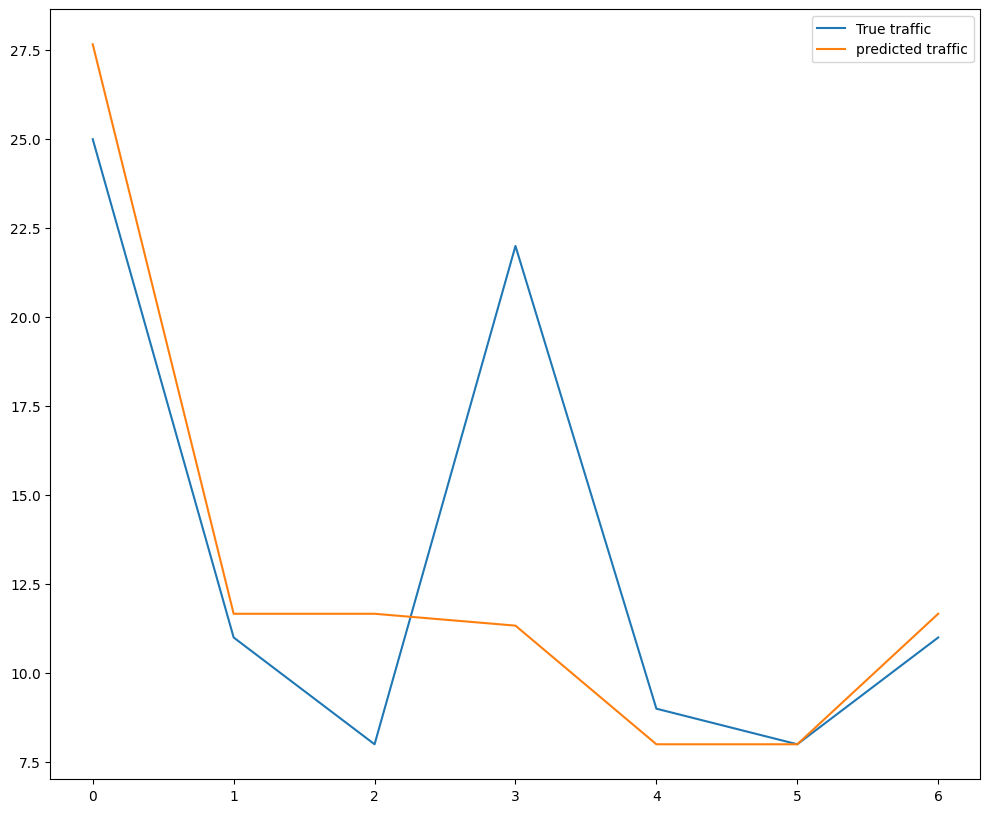

In [66]:
# show the prediction plot
plt.figure(1,figsize=(12,10))
plt.plot(range(len(y_test)),y_test,label='True traffic')
plt.plot(range(len(y_test)),y_pred,label='predicted traffic')
plt.legend()
plt.show()